## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import re
import math
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


## 2. Preparação do Dataset

In [2]:
PALAVRAS_SUSPEITAS_FILTRO = [
    'login', 'verify', 'secure', 'update', 'bank', 'paypal',
    'account', 'password', 'confirm', 'validate', 'signin',
    'wallet', 'billing', 'support', 'alert', 'security'
]

def tem_palavras_suspeitas(url):
    return any(p in str(url).lower() for p in PALAVRAS_SUSPEITAS_FILTRO)

# Dataset original
df_orig = pd.read_csv('urldata_clean.csv')
df_orig = df_orig.rename(columns={'domain': 'url'})[['url', 'label']]
print(f'Dataset original       : {len(df_orig):,} URLs')
print(df_orig['label'].value_counts().rename({0:'Benigno', 1:'Malicioso'}).to_string())

Dataset original       : 95,911 URLs
label
Benigno      48009
Malicioso    47902


In [3]:
# Benignos do malicious_phish com params mas sem palavras suspeitas
df_phish = pd.read_csv('malicious_phish.csv')
df_benignos_extra = df_phish[
    (df_phish['type'] == 'benign') &
    (df_phish['url'].str.contains(r'[?&]', na=False)) &
    (~df_phish['url'].apply(tem_palavras_suspeitas))
].copy()
df_benignos_extra['label'] = 0
df_benignos_extra = df_benignos_extra[['url', 'label']]
print(f'Benignos com params    : {len(df_benignos_extra):,} URLs')

Benignos com params    : 59,917 URLs


In [4]:
# Top 1000 domínios Tranco — com variantes de protocolo
df_tranco = pd.read_csv('top-1m.csv', header=None, names=['rank', 'domain'])
df_tranco_top = df_tranco.head(1000).copy()
linhas = []
for _, row in df_tranco_top.iterrows():
    dom = row['domain']
    linhas.append({'url': dom,               'label': 0})
    linhas.append({'url': f'http://{dom}',   'label': 0})
    linhas.append({'url': f'https://{dom}',  'label': 0})

df_tranco_final = pd.DataFrame(linhas)
print(f'Top domínios Tranco (c/ variantes) : {len(df_tranco_final):,} URLs')
print(f'  Exemplo: {df_tranco_final["url"].head(3).tolist()}')

Top domínios Tranco (c/ variantes) : 3,000 URLs
  Exemplo: ['google.com', 'http://google.com', 'https://google.com']


In [5]:
# Combinar
df = pd.concat([df_orig, df_benignos_extra, df_tranco_final], ignore_index=True)
df = df.dropna(subset=['url'])
df = df.drop_duplicates(subset=['url'])

contagem = df['label'].value_counts()
pct      = df['label'].value_counts(normalize=True) * 100
racio    = contagem.max() / contagem.min()
print(f'Dataset combinado:')
print(f'  Total         : {len(df):,} URLs')
print(f'  Benigno   (0) : {contagem[0]:,}  ({pct[0]:.1f}%)')
print(f'  Malicioso (1) : {contagem[1]:,}  ({pct[1]:.1f}%)')
print(f'  Racio         : {racio:.2f}:1')
cw = 'balanced' if racio > 2 else None
print(f'  class_weight  : {cw}')

Dataset combinado:
  Total         : 154,738 URLs
  Benigno   (0) : 106,837  (69.0%)
  Malicioso (1) : 47,901  (31.0%)
  Racio         : 2.23:1
  class_weight  : balanced


## 3. Extração das 27 Features Lexicais

In [6]:
ENCURTADORES = {
    'bit.ly', 'tinyurl.com', 'goo.gl', 't.co', 'ow.ly',
    'is.gd', 'buff.ly', 'adf.ly', 'short.link', 'rebrand.ly', 'tiny.cc'
}
TLDS_SUSPEITOS = {
    'tk', 'ml', 'ga', 'cf', 'gq', 'xyz', 'top', 'club', 'work',
    'info', 'biz', 'click', 'link', 'online', 'site', 'website'
}
PALAVRAS_SUSPEITAS = [
    'login', 'verify', 'secure', 'update', 'bank', 'paypal',
    'account', 'password', 'confirm', 'validate', 'signin',
    'wallet', 'billing', 'support', 'alert', 'security'
]

def calcular_entropia(texto):
    if not texto: return 0.0
    f = {}
    for c in texto:
        f[c] = f.get(c, 0) + 1
    e = 0.0
    for v in f.values():
        p = v / len(texto)
        e -= p * math.log2(p)
    return round(e, 4)

print('Listas configuradas.')

Listas configuradas.


In [7]:
def extrair_features(url):
    url = str(url).strip()

    # PASSO 1: Normalizar www. ANTES de qualquer calculo
    if url.startswith(('http://www.', 'https://www.')):
        url = url.replace('://www.', '://', 1)
    elif url.startswith('www.'):
        url = url[4:]

    # PASSO 2: Fazer parse do URL normalizado
    dominio = ''
    path    = ''
    query   = ''
    esquema = ''
    porto   = None
    try:
        if not url.startswith(('http://', 'https://')):
            parsed = urlparse('http://' + url)
        else:
            parsed = urlparse(url)
        dominio = parsed.netloc or parsed.path.split('/')[0]
        path    = parsed.path
        query   = parsed.query
        esquema = parsed.scheme
        try:
            porto = parsed.port
        except ValueError:
            porto = None
    except ValueError:
        pass

    # PASSO 3: Calcular features (dominio ja nao tem www.)
    dominio_limpo = dominio  # www. ja foi removido no passo 1
    partes_dom    = dominio_limpo.split('.')
    tld           = partes_dom[-1].lower() if len(partes_dom) > 1 else ''
    url_lower     = url.lower()
    comp_url      = len(url)
    n_digitos     = sum(c.isdigit() for c in url)
    n_hifenes     = url.count('-')
    n_underscore  = url.count('_')
    n_percent     = url.count('%')
    n_iguais      = url.count('=')

    return {
        'lex_comp_url'            : comp_url,
        'lex_comp_dominio'        : len(dominio_limpo),
        'lex_comp_path'           : len(path),
        'lex_n_pontos'            : url.count('.'),
        'lex_n_hifenes'           : n_hifenes,
        'lex_n_subdominios'       : max(0, len(dominio_limpo.split('.')) - 2),
        'lex_n_digitos'           : n_digitos,
        'lex_n_barras'            : url.count('/'),
        'lex_n_iguais'            : n_iguais,
        'lex_n_ampersands'        : url.count('&'),
        'lex_n_percent'           : n_percent,
        'lex_n_underscores'       : n_underscore,
        'lex_n_params'            : len([p for p in query.split('&') if p]),
        'lex_ratio_digitos'       : round(n_digitos / comp_url, 4) if comp_url > 0 else 0,
        'lex_ratio_especiais'     : round((n_hifenes + n_underscore + n_percent + n_iguais) / comp_url, 4) if comp_url > 0 else 0,
        'lex_profundidade'        : len([p for p in path.split('/') if p]),
        'lex_tem_https'           : 1 if esquema == 'https' else 0,
        'lex_tem_ip'              : 1 if re.match(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', dominio) else 0,
        'lex_tem_arroba'          : 1 if '@' in url else 0,
        'lex_tem_http_no_path'    : 1 if 'http' in path.lower() else 0,
        'lex_tld_suspeito'        : 1 if tld in TLDS_SUSPEITOS else 0,
        'lex_encurtador'          : 1 if any(e in url_lower for e in ENCURTADORES) else 0,
        'lex_porto_suspeito'      : 1 if (porto and porto not in {80, 443, 8080}) else 0,
        'lex_digitos_consecutivos': 1 if re.search(r'\d{3,}', dominio_limpo) else 0,
        'lex_palavras_suspeitas'  : sum(1 for p in PALAVRAS_SUSPEITAS if p in url_lower),
        'lex_entropia_dominio'    : calcular_entropia(dominio_limpo),
        'lex_entropia_url'        : calcular_entropia(url),
    }

# Verificacao obrigatoria — todos devem dar o mesmo resultado
print('=== VERIFICACAO www. ===')
urls_teste = ['google.com', 'www.google.com',
              'youtube.com', 'www.youtube.com',
              'https://youtube.com', 'https://www.youtube.com']
for u in urls_teste:
    f = extrair_features(u)
    print(f'  {u:<35} comp_url={f["lex_comp_url"]:3d}  comp_dom={f["lex_comp_dominio"]:3d}  subdominios={f["lex_n_subdominios"]}')
print()
# Confirmar que pares sao identicos
assert extrair_features('google.com') == extrair_features('www.google.com'), 'ERRO: google.com != www.google.com'
assert extrair_features('youtube.com') == extrair_features('www.youtube.com'), 'ERRO: youtube.com != www.youtube.com'
assert extrair_features('https://youtube.com') == extrair_features('https://www.youtube.com'), 'ERRO: https'
print('OK — todos os pares sao identicos!')

=== VERIFICACAO www. ===
  google.com                          comp_url= 10  comp_dom= 10  subdominios=0
  www.google.com                      comp_url= 10  comp_dom= 10  subdominios=0
  youtube.com                         comp_url= 11  comp_dom= 11  subdominios=0
  www.youtube.com                     comp_url= 11  comp_dom= 11  subdominios=0
  https://youtube.com                 comp_url= 19  comp_dom= 11  subdominios=0
  https://www.youtube.com             comp_url= 19  comp_dom= 11  subdominios=0

OK — todos os pares sao identicos!


In [8]:
print('A extrair features... (1-3 minutos)')
features_df = df['url'].apply(extrair_features).apply(pd.Series)
df_final = pd.concat(
    [df[['url', 'label']].reset_index(drop=True),
     features_df.reset_index(drop=True)], axis=1
)
print(f'Concluido! {df_final.shape}')
print(f'Nulos: {features_df.isnull().sum().sum()} — OK')

A extrair features... (1-3 minutos)
Concluido! (154738, 29)
Nulos: 0 — OK


## 4. Treino

In [9]:
X = df_final[features_df.columns]
y = df_final['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

racio = y.value_counts().max() / y.value_counts().min()
cw = 'balanced' if racio > 2 else None
print(f'Treino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,} | class_weight={cw}')

modelo = RandomForestClassifier(
    n_estimators=500,
    max_features=0.5,
    min_samples_split=5,
    class_weight=cw,
    random_state=42,
    n_jobs=-1
)
print('A treinar...')
modelo.fit(X_train, y_train)
print('Concluido!')

Treino: 123,790 | Teste: 30,948 | class_weight=balanced
A treinar...
Concluido!


## 5. Avaliação

In [10]:
y_pred  = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print('=' * 50)
print('  METRICAS — MODELO FINAL v3')
print('=' * 50)
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')
print(f'  AUC-ROC   : {auc*100:.2f}%')
print('=' * 50)
print()
print(classification_report(y_test, y_pred,
      target_names=['Benigno (0)', 'Malicioso (1)']))

  METRICAS — MODELO FINAL v3
  Accuracy  : 94.65%
  Precision : 93.68%
  Recall    : 88.71%
  F1-Score  : 91.13%
  AUC-ROC   : 98.40%

               precision    recall  f1-score   support

  Benigno (0)       0.95      0.97      0.96     21368
Malicioso (1)       0.94      0.89      0.91      9580

     accuracy                           0.95     30948
    macro avg       0.94      0.93      0.94     30948
 weighted avg       0.95      0.95      0.95     30948



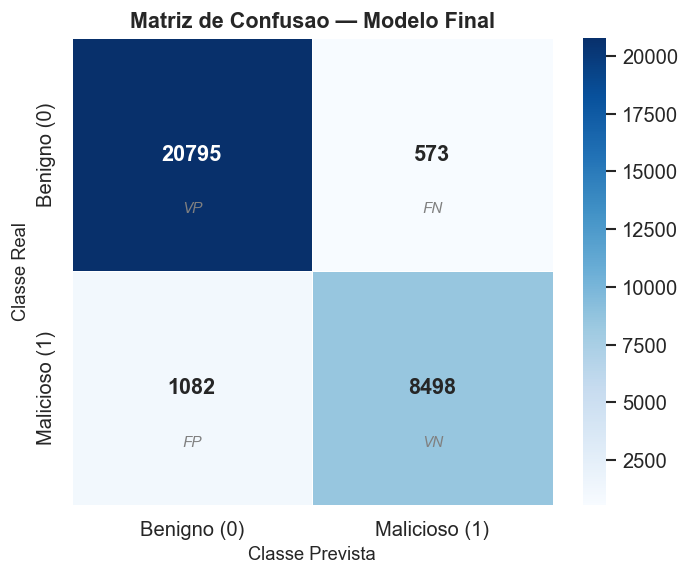

VP=20,795  FN=573  FP=1,082  VN=8,498


In [11]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno (0)', 'Malicioso (1)'],
            yticklabels=['Benigno (0)', 'Malicioso (1)'],
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'})
ax.set_xlabel('Classe Prevista', fontsize=11)
ax.set_ylabel('Classe Real', fontsize=11)
ax.set_title('Matriz de Confusao — Modelo Final', fontweight='bold', fontsize=13)
labels_cm = [['VP', 'FN'], ['FP', 'VN']]
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.75, labels_cm[i][j], ha='center',
                fontsize=9, color='grey', style='italic')
plt.tight_layout()
plt.savefig('fig_confusao_modelo_final.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'VP={cm[0,0]:,}  FN={cm[0,1]:,}  FP={cm[1,0]:,}  VN={cm[1,1]:,}')

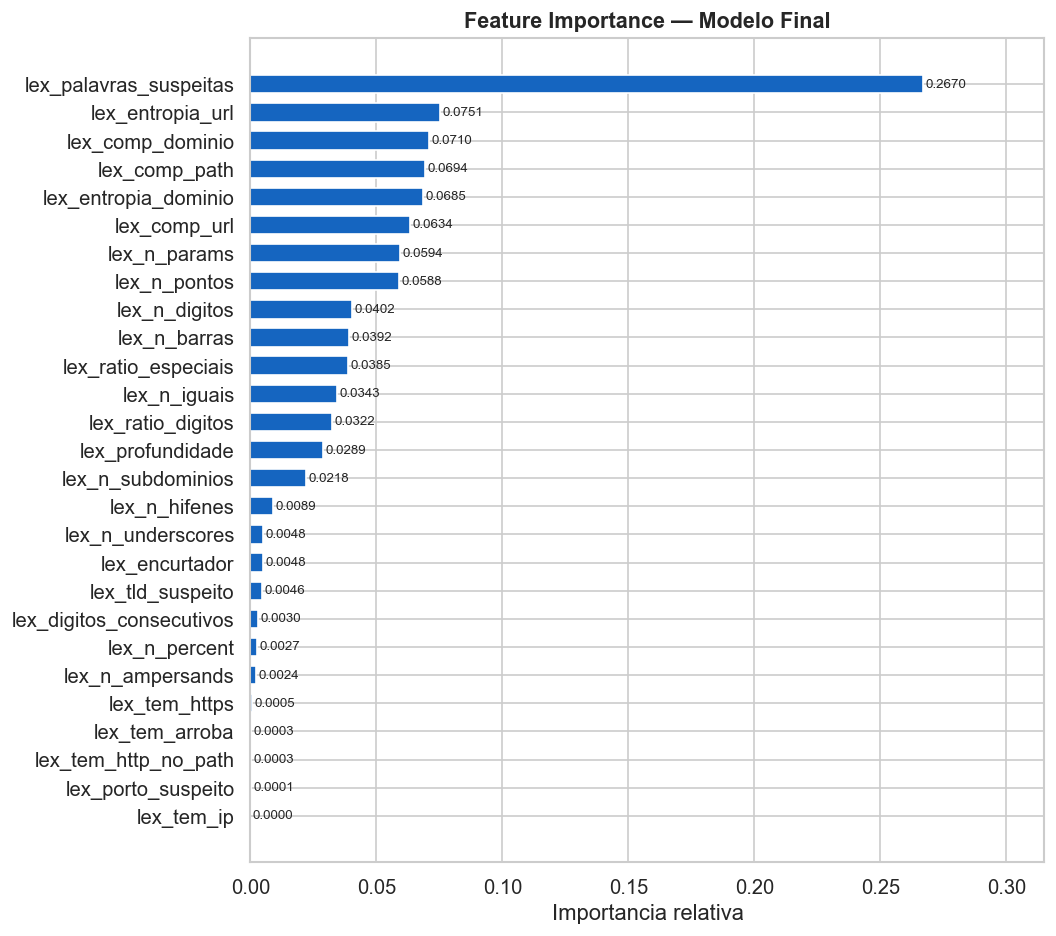

Top 5:
  lex_palavras_suspeitas      : 0.2670
  lex_entropia_url            : 0.0751
  lex_comp_dominio            : 0.0710
  lex_comp_path               : 0.0694
  lex_entropia_dominio        : 0.0685


In [12]:
importancias = pd.Series(
    modelo.feature_importances_, index=X.columns
).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(importancias.index, importancias.values,
        color='#1565c0', edgecolor='white', height=0.65)
for i, (feat, val) in enumerate(importancias.items()):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)
ax.set_title('Feature Importance — Modelo Final', fontweight='bold', fontsize=13)
ax.set_xlabel('Importancia relativa')
ax.set_xlim(0, importancias.max() * 1.18)
plt.tight_layout()
plt.savefig('fig_importance_modelo_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 5:')
for feat, val in importancias.nlargest(5).items():
    print(f'  {feat:<28}: {val:.4f}')

## 6. Teste com URLs Reais

In [13]:
urls_validacao = [
    ('google.com',              'BENIGNO'),
    ('www.google.com',          'BENIGNO'),
    ('youtube.com',             'BENIGNO'),
    ('www.youtube.com',         'BENIGNO'),
    ('https://www.youtube.com', 'BENIGNO'),
    ('https://www.google.com/search?client=opera&q=pombo+bebes&sourceid=opera&ie=UTF-8&oe=UTF-8', 'BENIGNO'),
    ('github.com/scikit-learn/scikit-learn',                          'BENIGNO'),
    ('https://www.amazon.com/dp/B08N5WRWNW?ref=cm_sw_r_cp_ud_dp',    'BENIGNO'),
    ('serviciosbys.com/paypal.cgi.bin.secure/verify/login.php',       'MALICIOSO'),
    ('nobell.it/paypal.verify.secure/index.php?cmd=login-run',        'MALICIOSO'),
    ('signin.eby.de.zukruygxctzmmqi.civpro.co.za',                    'MALICIOSO'),
    ('br-icloud.com.br',                                              'MALICIOSO'),
    ('http://192.168.1.1/admin/login',                                'MALICIOSO'),
]

print(f'{"URL":<62} {"Esperado":<12} {"Previsto":<12} {"Prob Mal":>9}')
print('-' * 100)
corretos = 0
for url, esperado in urls_validacao:
    f = extrair_features(url)
    X_val = pd.DataFrame([f])[X.columns]
    pred  = modelo.predict(X_val)[0]
    prob  = modelo.predict_proba(X_val)[0][1] * 100
    label_pred = 'MALICIOSO' if pred == 1 else 'BENIGNO'
    ok = 'OK' if label_pred == esperado else 'ERRO'
    if ok == 'OK': corretos += 1
    print(f'{url[:61]:<62} {esperado:<12} {label_pred:<12} {prob:>8.1f}%  {ok}')
print(f'\nResultado: {corretos}/{len(urls_validacao)} corretos')

URL                                                            Esperado     Previsto      Prob Mal
----------------------------------------------------------------------------------------------------
google.com                                                     BENIGNO      BENIGNO           0.0%  OK
www.google.com                                                 BENIGNO      BENIGNO           0.0%  OK
youtube.com                                                    BENIGNO      BENIGNO           6.9%  OK
www.youtube.com                                                BENIGNO      BENIGNO           6.9%  OK
https://www.youtube.com                                        BENIGNO      BENIGNO           0.0%  OK
https://www.google.com/search?client=opera&q=pombo+bebes&sour  BENIGNO      BENIGNO           5.0%  OK
github.com/scikit-learn/scikit-learn                           BENIGNO      BENIGNO           9.9%  OK
https://www.amazon.com/dp/B08N5WRWNW?ref=cm_sw_r_cp_ud_dp      BENIGNO      BEN

## 7. Guardar Modelo

In [14]:
joblib.dump(modelo, 'modelo_rf_final.pkl')
print('Modelo guardado: modelo_rf_final.pkl')
m = joblib.load('modelo_rf_final.pkl')
print(f'OK — {m.n_estimators} arvores, {m.n_features_in_} features')

Modelo guardado: modelo_rf_final.pkl
OK — 500 arvores, 27 features
